In [1]:
import pandas as pd

In [2]:
path = "C:/Users/vihaa/Desktop/Solar Panel/Solar Panel Fault Detection"

path = r"C:\Users\vihaa\Desktop\Solar Panel\Solar Panel Fault Detection
unicodeescape

In [3]:
solar = pd.read_csv(path + "/backend/data/timeseries/raw/Solar_Energy_Generation.csv")
weather=pd.read_csv(path+"/backend/data/timeseries/raw/Weather_Data_reordered_all.csv")

In [4]:
print(solar.head())
solar.shape

   CampusKey  SiteKey            Timestamp  SolarGeneration
0          2        1  2020-01-01 00:15:00              NaN
1          2        1  2020-01-01 00:30:00              NaN
2          2        1  2020-01-01 00:45:00              NaN
3          2        1  2020-01-01 01:00:00              NaN
4          2        1  2020-01-01 01:15:00              NaN


(2731946, 4)

Visualise Dataset (Used Kaggle Summary)

In [5]:
solar['Timestamp']=pd.to_datetime(solar['Timestamp'])

Solution:-Identify problems in both the datasets

In [6]:
site1=solar[solar["SiteKey"]==1]
#Time series is ordered and if not then make it ordered (by sorting)

In [7]:
site1.isna().sum()

CampusKey              0
SiteKey                0
Timestamp              0
SolarGeneration    41746
dtype: int64

In [8]:
(site1['SolarGeneration'].isna().sum() / len(site1)) * 100

np.float64(52.6305172783318)

In [9]:
counts = site1.groupby(site1['Timestamp'].dt.hour)['SolarGeneration'].agg(
    total='size',
    nan_count=lambda x: x.isna().sum(),
    not_nan_count=lambda x: x.notna().sum()
)

In [10]:
print(counts)

           total  nan_count  not_nan_count
Timestamp                                 
0           3308       3308              0
1           3320       3320              0
2           3321       3321              0
3           3323       3323              0
4           3321       3321              0
5           3316       3316              0
6           3316       2730            586
7           3315        987           2328
8           3310        115           3195
9           3308         84           3224
10          3308         68           3240
11          3308        143           3165
12          3305        315           2990
13          3301        362           2939
14          3300        222           3078
15          3300         73           3227
16          3302         53           3249
17          3301        657           2644
18          3296       1471           1825
19          3296       1813           1483
20          3296       2896            400
21         

Month	Sunrise	Sunset	Day Length
Jan	earliest	latest	longest
Feb	slightly later	slightly earlier	↓
Mar	increasing	decreasing	medium
Apr	later	earlier	↓
May	later	earlier	↓
Jun	latest	earliest	shortest
Jul	slightly earlier	slightly later	↑
Aug	earlier	later	↑
Sep	balanced	balanced	medium
Oct	earlier	later	↑
Nov	early	late	↑
Dec	earliest	latest	longest

In [11]:
site1 = site1.copy()

In [12]:
time_diff = site1['Timestamp'].sort_values().diff()

print(time_diff.value_counts())

Timestamp
0 days 00:15:00    79303
0 days 22:00:00        1
1 days 06:30:00        1
0 days 09:00:00        1
2 days 01:30:00        1
4 days 00:15:00        1
2 days 02:45:00        1
0 days 19:30:00        1
1 days 03:30:00        1
0 days 01:45:00        1
0 days 11:15:00        1
0 days 12:15:00        1
1 days 03:00:00        1
1 days 16:00:00        1
0 days 01:15:00        1
1 days 07:15:00        1
Name: count, dtype: int64


In [13]:
site1 = site1.set_index('Timestamp').sort_index()
site1 = site1.asfreq('15T')

C:\Users\vihaa\AppData\Local\Temp\ipykernel_59512\2035786978.py:2: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  site1 = site1.asfreq('15T')


(Option that we are not pursuing right now) Remove night ✅. We are not doing this right now.

In [14]:
import numpy as np

def process_day(df):
    df = df.copy()
    
    values = df['SolarGeneration'].values
    #Will code numpy after this project or in future projects when we don't have a due date
    valid_idx = np.where(values > 0)[0]
    
    if len(valid_idx) == 0:
        df['SolarGeneration'] = 0
        return df
    #Entire day has 0 solar generation 
    first_valid = valid_idx[0]
    last_valid = valid_idx[-1]
    
    col_idx = df.columns.get_loc('SolarGeneration')
    
    df.iloc[:first_valid, col_idx] = 0
    df.iloc[last_valid+1:, col_idx] = 0
    
    middle = df.iloc[first_valid:last_valid+1].copy()
    
    middle['SolarGeneration'] = middle['SolarGeneration'].replace(0, np.nan)
    middle['SolarGeneration'] = middle['SolarGeneration'].interpolate(
        method='linear',
        limit_direction='both'
    )
    
    df.iloc[first_valid:last_valid+1] = middle
    #Only middle values are interpolated
    return df


# ✅ DO NOT set index again
# site1 = site1.set_index('Timestamp') ❌ REMOVE

# ✅ Just ensure sorted
site1 = site1.sort_index()

# ✅ Apply preprocessing
site1 = site1.groupby(site1.index.date, group_keys=False).apply(process_day)

# ✅ Final cleanup
site1['SolarGeneration'] = site1['SolarGeneration'].fillna(0)
site1[['CampusKey', 'SiteKey']] = site1[['CampusKey', 'SiteKey']].ffill().bfill()

In [15]:
site1.isna().sum()

CampusKey          0
SiteKey            0
SolarGeneration    0
dtype: int64

In [16]:
site1

,CampusKey,SiteKey,SolarGeneration
Timestamp,,,
2020-01-01 00:15:00,2.0,1.0,0.0
2020-01-01 00:30:00,2.0,1.0,0.0
2020-01-01 00:45:00,2.0,1.0,0.0
2020-01-01 01:00:00,2.0,1.0,0.0
2020-01-01 01:15:00,2.0,1.0,0.0
...,...,...,...
2022-04-23 22:45:00,2.0,1.0,0.0
2022-04-23 23:00:00,2.0,1.0,0.0
2022-04-23 23:15:00,2.0,1.0,0.0


In [17]:
site1['hour'] = site1.index.hour
site1['day'] = site1.index.day
site1['month'] = site1.index.month
site1['day_of_week'] = site1.index.dayofweek

In [19]:
site1

,CampusKey,SiteKey,SolarGeneration,hour,day,month,day_of_week
Timestamp,,,,,,,
2020-01-01 00:15:00,2.0,1.0,0.0,0,1,1,2
2020-01-01 00:30:00,2.0,1.0,0.0,0,1,1,2
2020-01-01 00:45:00,2.0,1.0,0.0,0,1,1,2
2020-01-01 01:00:00,2.0,1.0,0.0,1,1,1,2
2020-01-01 01:15:00,2.0,1.0,0.0,1,1,1,2
...,...,...,...,...,...,...,...
2022-04-23 22:45:00,2.0,1.0,0.0,22,23,4,5
2022-04-23 23:00:00,2.0,1.0,0.0,23,23,4,5
2022-04-23 23:15:00,2.0,1.0,0.0,23,23,4,5


In [20]:
weather['Timestamp'] = pd.to_datetime(weather['Timestamp'])

In [21]:
weather.isna().sum()

CampusKey                   0
Timestamp                   0
ApparentTemperature    107113
AirTemperature         107113
DewPointTemperature    107113
RelativeHumidity       107113
WindSpeed              162890
WindDirection          162890
dtype: int64

In [22]:
weather.head()

,CampusKey,Timestamp,ApparentTemperature,AirTemperature,DewPointTemperature,RelativeHumidity,WindSpeed,WindDirection
0,1,2020-01-01 00:00:00,13.666667,13.880000,8.960000,72.400000,0.000000,188.133333
1,1,2020-01-01 00:15:00,13.206667,13.666667,9.040000,73.466667,1.200000,203.866667
2,1,2020-01-01 00:30:00,12.840000,13.553333,9.053333,74.000000,2.520000,222.800000
3,1,2020-01-01 00:45:00,12.113333,13.506667,9.100000,74.466667,5.986667,231.133333
4,1,2020-01-01 01:00:00,11.946667,13.260000,9.266667,76.533333,5.946667,247.866667


In [23]:
wcampus2=weather[weather["CampusKey"]==2]

In [24]:
wcampus2.head()

,CampusKey,Timestamp,ApparentTemperature,AirTemperature,DewPointTemperature,RelativeHumidity,WindSpeed,WindDirection
81017,2,2020-01-01 00:00:00,17.986667,20.140000,9.173333,49.200000,10.120000,180.666667
81018,2,2020-01-01 00:15:00,18.560000,20.300000,9.600000,50.266667,8.680000,152.666667
81019,2,2020-01-01 00:30:00,18.146667,19.840000,9.340000,50.666667,7.933333,157.533333
81020,2,2020-01-01 00:45:00,18.140000,19.886667,9.486667,51.000000,8.440000,147.600000
81021,2,2020-01-01 01:00:00,17.693333,19.540000,9.180000,51.133333,8.680000,151.333333


In [25]:
wcampus2.isna().sum()

CampusKey                  0
Timestamp                  0
ApparentTemperature    12763
AirTemperature         12763
DewPointTemperature    12763
RelativeHumidity       12763
WindSpeed              26042
WindDirection          26042
dtype: int64

In [26]:
wcampus2 = weather[weather["CampusKey"] == 2].copy()
#Copy?

In [27]:
wcampus2['Timestamp'].is_monotonic_increasing

True

In [28]:
wcampus2 = wcampus2.sort_values('Timestamp')

In [29]:
print(wcampus2.isna().sum())

CampusKey                  0
Timestamp                  0
ApparentTemperature    12763
AirTemperature         12763
DewPointTemperature    12763
RelativeHumidity       12763
WindSpeed              26042
WindDirection          26042
dtype: int64


In [30]:
w_time_diff = wcampus2['Timestamp'].sort_values().diff()

print(w_time_diff.value_counts())

Timestamp
0 days 00:15:00    81016
Name: count, dtype: int64


In [31]:
wcampus2 = wcampus2.set_index('Timestamp')

In [32]:
#duplicate
wcampus2 = wcampus2[~wcampus2.index.duplicated(keep='first')]

In [33]:
wcampus2.index.duplicated().sum()

np.int64(0)

In [34]:
full_time = pd.date_range(
    start=wcampus2.index.min(),
    end=wcampus2.index.max(),
    freq='15T'
)

wcampus2 = wcampus2.reindex(full_time)
#I think here we have the entire time

C:\Users\vihaa\AppData\Local\Temp\ipykernel_59512\2909523129.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_time = pd.date_range(


In [35]:
wcampus2.isna().sum()

CampusKey                  0
ApparentTemperature    12763
AirTemperature         12763
DewPointTemperature    12763
RelativeHumidity       12763
WindSpeed              26042
WindDirection          26042
dtype: int64

reates a complete timeline from the earliest timestamp → latest timestamp
freq='15T' means every 15 minutes
So even if your data skipped times (like missing 10:45), this will include it

In [36]:
wcampus2 = wcampus2.interpolate(method='time')

In [37]:
wcampus2.isna().sum()

CampusKey              0
ApparentTemperature    0
AirTemperature         0
DewPointTemperature    0
RelativeHumidity       0
WindSpeed              0
WindDirection          0
dtype: int64

In [38]:
wcampus2 = wcampus2.reset_index()

In [39]:
print(wcampus2.head())
print(wcampus2.shape)

                index  CampusKey  ApparentTemperature  AirTemperature  \
0 2020-01-01 00:00:00          2            17.986667       20.140000   
1 2020-01-01 00:15:00          2            18.560000       20.300000   
2 2020-01-01 00:30:00          2            18.146667       19.840000   
3 2020-01-01 00:45:00          2            18.140000       19.886667   
4 2020-01-01 01:00:00          2            17.693333       19.540000   

   DewPointTemperature  RelativeHumidity  WindSpeed  WindDirection  
0             9.173333         49.200000  10.120000     180.666667  
1             9.600000         50.266667   8.680000     152.666667  
2             9.340000         50.666667   7.933333     157.533333  
3             9.486667         51.000000   8.440000     147.600000  
4             9.180000         51.133333   8.680000     151.333333  
(81017, 8)


Tomorrow understand what you completed until now and finish preprocessing
Tuesday:- Model is ready!

In [43]:
site1.head()

,CampusKey,SiteKey,SolarGeneration,hour,day,month,day_of_week
Timestamp,,,,,,,
2020-01-01 00:15:00,2.0,1.0,0.0,0,1,1,2
2020-01-01 00:30:00,2.0,1.0,0.0,0,1,1,2
2020-01-01 00:45:00,2.0,1.0,0.0,0,1,1,2
2020-01-01 01:00:00,2.0,1.0,0.0,1,1,1,2
2020-01-01 01:15:00,2.0,1.0,0.0,1,1,1,2


In [48]:
wcampus2 = wcampus2.drop(wcampus2.index[0])

In [49]:
wcampus2.head()

,index,CampusKey,ApparentTemperature,AirTemperature,DewPointTemperature,RelativeHumidity,WindSpeed,WindDirection
1,2020-01-01 00:15:00,2,18.560000,20.300000,9.600000,50.266667,8.680000,152.666667
2,2020-01-01 00:30:00,2,18.146667,19.840000,9.340000,50.666667,7.933333,157.533333
3,2020-01-01 00:45:00,2,18.140000,19.886667,9.486667,51.000000,8.440000,147.600000
4,2020-01-01 01:00:00,2,17.693333,19.540000,9.180000,51.133333,8.680000,151.333333
5,2020-01-01 01:15:00,2,17.613333,19.153333,9.053333,51.933333,6.866667,149.333333


In [51]:
wcampus2 = wcampus2.drop(wcampus2.index[0])

In [52]:
wcampus2.head()

,index,CampusKey,ApparentTemperature,AirTemperature,DewPointTemperature,RelativeHumidity,WindSpeed,WindDirection
2,2020-01-01 00:30:00,2,18.146667,19.840000,9.340000,50.666667,7.933333,157.533333
3,2020-01-01 00:45:00,2,18.140000,19.886667,9.486667,51.000000,8.440000,147.600000
4,2020-01-01 01:00:00,2,17.693333,19.540000,9.180000,51.133333,8.680000,151.333333
5,2020-01-01 01:15:00,2,17.613333,19.153333,9.053333,51.933333,6.866667,149.333333
6,2020-01-01 01:30:00,2,16.906667,18.873333,9.153333,53.266667,9.253333,163.466667


In [50]:
site1.head()

,CampusKey,SiteKey,SolarGeneration,hour,day,month,day_of_week
Timestamp,,,,,,,
2020-01-01 00:30:00,2.0,1.0,0.0,0,1,1,2
2020-01-01 00:45:00,2.0,1.0,0.0,0,1,1,2
2020-01-01 01:00:00,2.0,1.0,0.0,1,1,1,2
2020-01-01 01:15:00,2.0,1.0,0.0,1,1,1,2
2020-01-01 01:30:00,2.0,1.0,0.0,1,1,1,2


In [53]:
site1 = site1.reset_index()
wcampus2 = wcampus2.reset_index()

In [54]:
site1.head()

,Timestamp,CampusKey,SiteKey,SolarGeneration,hour,day,month,day_of_week
0,2020-01-01 00:30:00,2.0,1.0,0.0,0,1,1,2
1,2020-01-01 00:45:00,2.0,1.0,0.0,0,1,1,2
2,2020-01-01 01:00:00,2.0,1.0,0.0,1,1,1,2
3,2020-01-01 01:15:00,2.0,1.0,0.0,1,1,1,2
4,2020-01-01 01:30:00,2.0,1.0,0.0,1,1,1,2


In [55]:
wcampus2.head()


,level_0,index,CampusKey,ApparentTemperature,AirTemperature,DewPointTemperature,RelativeHumidity,WindSpeed,WindDirection
0,2,2020-01-01 00:30:00,2,18.146667,19.840000,9.340000,50.666667,7.933333,157.533333
1,3,2020-01-01 00:45:00,2,18.140000,19.886667,9.486667,51.000000,8.440000,147.600000
2,4,2020-01-01 01:00:00,2,17.693333,19.540000,9.180000,51.133333,8.680000,151.333333
3,5,2020-01-01 01:15:00,2,17.613333,19.153333,9.053333,51.933333,6.866667,149.333333
4,6,2020-01-01 01:30:00,2,16.906667,18.873333,9.153333,53.266667,9.253333,163.466667


In [56]:
wcampus2 = wcampus2.drop(columns=['level_0'], errors='ignore')

In [57]:
wcampus2.head()

,index,CampusKey,ApparentTemperature,AirTemperature,DewPointTemperature,RelativeHumidity,WindSpeed,WindDirection
0,2020-01-01 00:30:00,2,18.146667,19.840000,9.340000,50.666667,7.933333,157.533333
1,2020-01-01 00:45:00,2,18.140000,19.886667,9.486667,51.000000,8.440000,147.600000
2,2020-01-01 01:00:00,2,17.693333,19.540000,9.180000,51.133333,8.680000,151.333333
3,2020-01-01 01:15:00,2,17.613333,19.153333,9.053333,51.933333,6.866667,149.333333
4,2020-01-01 01:30:00,2,16.906667,18.873333,9.153333,53.266667,9.253333,163.466667


In [58]:
wcampus2 = wcampus2.rename(columns={'index': 'Timestamp'})

In [59]:
wcampus2.head()

,Timestamp,CampusKey,ApparentTemperature,AirTemperature,DewPointTemperature,RelativeHumidity,WindSpeed,WindDirection
0,2020-01-01 00:30:00,2,18.146667,19.840000,9.340000,50.666667,7.933333,157.533333
1,2020-01-01 00:45:00,2,18.140000,19.886667,9.486667,51.000000,8.440000,147.600000
2,2020-01-01 01:00:00,2,17.693333,19.540000,9.180000,51.133333,8.680000,151.333333
3,2020-01-01 01:15:00,2,17.613333,19.153333,9.053333,51.933333,6.866667,149.333333
4,2020-01-01 01:30:00,2,16.906667,18.873333,9.153333,53.266667,9.253333,163.466667


In [60]:
print(site1.columns)
print(wcampus2.columns)

Index(['Timestamp', 'CampusKey', 'SiteKey', 'SolarGeneration', 'hour', 'day',
       'month', 'day_of_week'],
      dtype='object')
Index(['Timestamp', 'CampusKey', 'ApparentTemperature', 'AirTemperature',
       'DewPointTemperature', 'RelativeHumidity', 'WindSpeed',
       'WindDirection'],
      dtype='object')


In [61]:
site1['Timestamp'] = pd.to_datetime(site1['Timestamp'])
wcampus2['Timestamp'] = pd.to_datetime(wcampus2['Timestamp'])

In [62]:
data = pd.merge(site1, wcampus2, on='Timestamp')

In [63]:
print(data.head())
print(data.shape)

            Timestamp  CampusKey_x  SiteKey  SolarGeneration  hour  day  \
0 2020-01-01 00:30:00          2.0      1.0              0.0     0    1   
1 2020-01-01 00:45:00          2.0      1.0              0.0     0    1   
2 2020-01-01 01:00:00          2.0      1.0              0.0     1    1   
3 2020-01-01 01:15:00          2.0      1.0              0.0     1    1   
4 2020-01-01 01:30:00          2.0      1.0              0.0     1    1   

   month  day_of_week  CampusKey_y  ApparentTemperature  AirTemperature  \
0      1            2            2            18.146667       19.840000   
1      1            2            2            18.140000       19.886667   
2      1            2            2            17.693333       19.540000   
3      1            2            2            17.613333       19.153333   
4      1            2            2            16.906667       18.873333   

   DewPointTemperature  RelativeHumidity  WindSpeed  WindDirection  
0             9.340000       

In [65]:
data.isna().sum()

Timestamp              0
CampusKey_x            0
SiteKey                0
SolarGeneration        0
hour                   0
day                    0
month                  0
day_of_week            0
CampusKey_y            0
ApparentTemperature    0
AirTemperature         0
DewPointTemperature    0
RelativeHumidity       0
WindSpeed              0
WindDirection          0
dtype: int64

In [66]:
data['lag_1'] = data['SolarGeneration'].shift(1)
data['lag_4'] = data['SolarGeneration'].shift(4)

In [67]:
data['rolling_mean_4'] = data['SolarGeneration'].rolling(4).mean()

In [68]:
data.isna().sum()

Timestamp              0
CampusKey_x            0
SiteKey                0
SolarGeneration        0
hour                   0
day                    0
month                  0
day_of_week            0
CampusKey_y            0
ApparentTemperature    0
AirTemperature         0
DewPointTemperature    0
RelativeHumidity       0
WindSpeed              0
WindDirection          0
lag_1                  1
lag_4                  4
rolling_mean_4         3
dtype: int64

In [69]:
data = data.dropna()

In [70]:
features = [
    'AirTemperature',
    'RelativeHumidity',
    'WindSpeed',
    'lag_1',
    'lag_4',
    'rolling_mean_4',
    'hour',
    'month'
]

X = data[features]
y = data['SolarGeneration']

In [71]:
print(X.head())
print(y.head())

   AirTemperature  RelativeHumidity  WindSpeed  lag_1  lag_4  rolling_mean_4  \
4       18.873333         53.266667   9.253333    0.0    0.0             0.0   
5       18.460000         53.666667   7.666667    0.0    0.0             0.0   
6       18.893333         53.133333   9.040000    0.0    0.0             0.0   
7       19.033333         52.000000   9.040000    0.0    0.0             0.0   
8       19.040000         52.000000  11.080000    0.0    0.0             0.0   

   hour  month  
4     1      1  
5     1      1  
6     2      1  
7     2      1  
8     2      1  
4    0.0
5    0.0
6    0.0
7    0.0
8    0.0
Name: SolarGeneration, dtype: float64


In [72]:
X.isna().sum()

AirTemperature      0
RelativeHumidity    0
WindSpeed           0
lag_1               0
lag_4               0
rolling_mean_4      0
hour                0
month               0
dtype: int64

In [73]:
split_index = int(len(data) * 0.8)

In [74]:
train = data.iloc[:split_index]
test = data.iloc[split_index:]

In [75]:
X_train = train[features]
y_train = train['SolarGeneration']

X_test = test[features]
y_test = test['SolarGeneration']

In [76]:
print(train['Timestamp'].min(), train['Timestamp'].max())
print(test['Timestamp'].min(), test['Timestamp'].max())

2020-01-01 01:30:00 2021-11-06 03:15:00
2021-11-06 03:30:00 2022-04-23 22:00:00


In [77]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [78]:
print("Model trained successfully")

Model trained successfully


In [79]:
pred = model.predict(X_test)

In [80]:
print(pred[:10])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [81]:
print(X_test.shape)

(16203, 8)


In [82]:
X_test.isna().sum()

AirTemperature      0
RelativeHumidity    0
WindSpeed           0
lag_1               0
lag_4               0
rolling_mean_4      0
hour                0
month               0
dtype: int64

In [83]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.45623302546521693
RMSE: 1.1533667051531813


In [84]:
print(y_test.describe())

count    16203.000000
mean         5.484351
std          7.275253
min          0.000000
25%          0.000000
50%          0.562500
75%         10.875000
max         21.750000
Name: SolarGeneration, dtype: float64


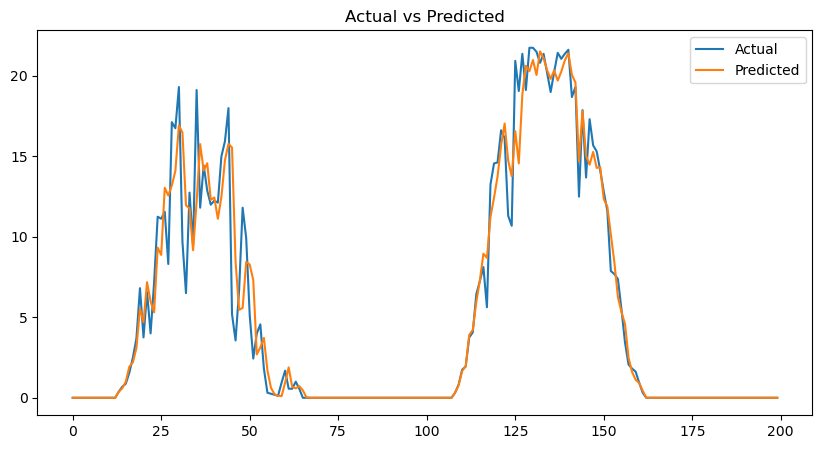

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:200], label='Actual')
plt.plot(pred[:200], label='Predicted')
plt.legend()
plt.title("Actual vs Predicted")
plt.show()